# Markowitz Mean-Variance Optimization (MPT)

This notebook implements Modern Portfolio Theory (MPT) as it would appear
inside a robo-advisor: the engine that finds the mathematically optimal
portfolio weights given a target risk tolerance.

Three portfolios are constructed and compared:
- **Maximum Sharpe** (Tangency) — best risk-adjusted return
- **Minimum Variance** — lowest achievable volatility
- **Equal Weight** — null-hypothesis baseline

Assets: `BND, GLD, TIP, TLT, VEU, VGT`

---
**Sections**
1. Imports & Config
2. Load Data
3. Expected Returns & Covariance Matrix
4. Efficient Frontier (Monte Carlo simulation)
5. Optimal Portfolio Weights (Max Sharpe & Min Variance)
6. Efficient Frontier — Analytical (scipy)
7. Weight Comparison
8. Cumulative Performance
9. Drawdown Paths
10. Rolling Weights (Rebalancing Simulation)
11. Performance Summary

In [1]:
# ── Cell 1: Imports & Config ─────────────────────────────────────────────────
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Load config ───────────────────────────────────────────────────────────────
MARKETS_FILE = Path("../../markets.json")
BASE         = Path("../../data")

with open(MARKETS_FILE) as f:
    config = json.load(f)

INITIAL_INVESTMENT = config["initial_investment"]
MONTHLY_INVESTMENT = config["monthly_investment"]
name               = list(config["markets"].keys())[0]

price_file   = BASE / f"{name}_prices_monthly.csv"
returns_file = BASE / f"{name}_returns_monthly.csv"

# ── Constants ─────────────────────────────────────────────────────────────────
RISK_FREE_ANNUAL  = 0.0351
RISK_FREE_MONTHLY = (1 + RISK_FREE_ANNUAL) ** (1/12) - 1
N_SIMULATIONS     = 10_000     # Monte Carlo portfolios for frontier visualization

CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]

# ── Plot style ────────────────────────────────────────────────────────────────
PALETTE = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]
plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market        : {name}")
print(f"Risk-free     : {RISK_FREE_ANNUAL*100:.2f}% annual  /  {RISK_FREE_MONTHLY*100:.4f}% monthly")
print(f"Simulations   : {N_SIMULATIONS:,}")
print(f"Initial cap   : ${INITIAL_INVESTMENT:,}")

Market        : primary_total_market
Risk-free     : 3.51% annual  /  0.2879% monthly
Simulations   : 10,000
Initial cap   : $1,000


In [2]:
# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
rets      = pd.read_csv(returns_file, index_col=0, parse_dates=True)
act_price = pd.read_csv(price_file,   index_col=0, parse_dates=True)

ASSETS = list(rets.columns)
N      = len(ASSETS)

print(f"Returns : {rets.shape}   {rets.index[0].date()} -> {rets.index[-1].date()}")
print(f"Assets  : {ASSETS}")
print(f"NaNs    : {rets.isnull().sum().sum()}  {'OK' if rets.isnull().sum().sum()==0 else 'CHECK'}")

Returns : (224, 6)   2007-05-01 -> 2025-12-01
Assets  : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
NaNs    : 0  OK


In [3]:
# ── Cell 3: Expected Returns & Covariance Matrix ──────────────────────────────
#
# MPT inputs:
#   mu  — annualized mean return vector  (N,)
#   cov — annualized covariance matrix   (N x N)
#
# Both annualized from monthly data (*12 and *12 respectively).
# The covariance scales linearly with time: monthly_cov * 12 = annual_cov.

mu  = rets.mean() * 12            # annualized expected returns
cov = rets.cov()  * 12            # annualized covariance matrix
vol = np.sqrt(np.diag(cov.values)) * 100   # annualized vol % per asset

print("── Annualized Expected Returns (%) ──")
print((mu * 100).round(2).to_string())

print("\n── Annualized Volatility (%) ──")
for a, v in zip(ASSETS, vol):
    print(f"  {a:<6}  {v:.2f}%")

print("\n── Correlation Matrix ──")
print(rets.corr().round(3).to_string())

── Annualized Expected Returns (%) ──
BND     3.11
GLD    10.98
TIP     3.54
TLT     3.97
VEU     5.99
VGT    16.92

── Annualized Volatility (%) ──
  BND     4.67%
  GLD     16.96%
  TIP     6.04%
  TLT     14.25%
  VEU     18.00%
  VGT     19.74%

── Correlation Matrix ──
       BND    GLD    TIP    TLT    VEU    VGT
BND  1.000  0.410  0.786  0.823  0.312  0.225
GLD  0.410  1.000  0.455  0.263  0.242  0.034
TIP  0.786  0.455  1.000  0.603  0.391  0.294
TLT  0.823  0.263  0.603  1.000 -0.071 -0.082
VEU  0.312  0.242  0.391 -0.071  1.000  0.763
VGT  0.225  0.034  0.294 -0.082  0.763  1.000


## 1. Efficient Frontier — Monte Carlo

In [4]:
# ── Cell 4: Efficient Frontier — Monte Carlo Simulation ───────────────────────
#
# Randomly generate N_SIMULATIONS portfolios with random weights.
# Each point = one portfolio's (annualized vol, annualized return, Sharpe).
# The upper-left boundary of the cloud IS the efficient frontier.
#
# This is purely for visualization — optimal weights are solved analytically
# in the next cell using scipy.

sim_returns = np.zeros(N_SIMULATIONS)
sim_vols    = np.zeros(N_SIMULATIONS)
sim_sharpes = np.zeros(N_SIMULATIONS)
sim_weights = np.zeros((N_SIMULATIONS, N))

cov_arr = cov.values
mu_arr  = mu.values

for i in range(N_SIMULATIONS):
    w = np.random.dirichlet(np.ones(N))    # random weights summing to 1
    r = w @ mu_arr
    v = np.sqrt(w @ cov_arr @ w)
    s = (r - RISK_FREE_ANNUAL) / v

    sim_returns[i] = r
    sim_vols[i]    = v
    sim_sharpes[i] = s
    sim_weights[i] = w

sim_df = pd.DataFrame({
    "Return" : sim_returns * 100,
    "Vol"    : sim_vols    * 100,
    "Sharpe" : sim_sharpes,
})

print(f"Simulated {N_SIMULATIONS:,} portfolios")
print(f"Return range : {sim_df['Return'].min():.1f}% -> {sim_df['Return'].max():.1f}%")
print(f"Vol range    : {sim_df['Vol'].min():.1f}% -> {sim_df['Vol'].max():.1f}%")
print(f"Sharpe range : {sim_df['Sharpe'].min():.3f} -> {sim_df['Sharpe'].max():.3f}")

Simulated 10,000 portfolios
Return range : 3.5% -> 16.2%
Vol range    : 5.1% -> 18.6%
Sharpe range : 0.005 -> 0.768


## 2. Optimal Portfolio Weights

In [5]:
# ── Cell 5: Solve for Optimal Portfolios (scipy SLSQP) ───────────────────────
#
# Two key portfolios on the efficient frontier:
#
# 1. MAXIMUM SHARPE (Tangency Portfolio)
#    Maximizes (mu - Rf) / sigma — the Capital Market Line tangency point.
#    This is what a robo-advisor targets for a "balanced growth" profile.
#
# 2. MINIMUM VARIANCE
#    Minimizes portfolio volatility regardless of return.
#    This is what a robo-advisor targets for a "capital preservation" profile.
#
# Constraints: weights >= 0 (long-only), sum(weights) = 1

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds      = [(0.0, 1.0)] * N
w0          = np.ones(N) / N

# ── Maximum Sharpe ────────────────────────────────────────────────────────────
def neg_sharpe(w):
    r = w @ mu_arr
    v = np.sqrt(w @ cov_arr @ w)
    return -(r - RISK_FREE_ANNUAL) / v

res_sharpe = sco.minimize(
    neg_sharpe, w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
w_sharpe = pd.Series(res_sharpe.x, index=ASSETS)

# ── Minimum Variance ──────────────────────────────────────────────────────────
def port_variance(w):
    return w @ cov_arr @ w

res_minvar = sco.minimize(
    port_variance, w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)
w_minvar = pd.Series(res_minvar.x, index=ASSETS)

# ── Equal Weight ──────────────────────────────────────────────────────────────
w_equal = pd.Series(1 / N, index=ASSETS)

# ── Summary ───────────────────────────────────────────────────────────────────
def portfolio_metrics(w, label):
    w = w.values
    r = w @ mu_arr
    v = np.sqrt(w @ cov_arr @ w)
    s = (r - RISK_FREE_ANNUAL) / v
    return {"Portfolio": label, "Return %": round(r*100, 2),
            "Vol %": round(v*100, 2), "Sharpe": round(s, 3)}

metrics = pd.DataFrame([
    portfolio_metrics(w_sharpe, "Max Sharpe"),
    portfolio_metrics(w_minvar, "Min Variance"),
    portfolio_metrics(w_equal,  "Equal Weight"),
]).set_index("Portfolio")

print("── Optimal Portfolio Metrics (annualized) ──")
print(metrics.to_string())

print("\n── Max Sharpe Weights (%) ──")
print((w_sharpe * 100).round(2).to_string())

print("\n── Min Variance Weights (%) ──")
print((w_minvar * 100).round(2).to_string())

── Optimal Portfolio Metrics (annualized) ──
              Return %  Vol %  Sharpe
Portfolio                            
Max Sharpe       14.41  13.67   0.797
Min Variance      3.15   4.67  -0.077
Equal Weight      7.42   8.64   0.452

── Max Sharpe Weights (%) ──
BND     0.00
GLD    42.21
TIP     0.00
TLT     0.00
VEU     0.00
VGT    57.79

── Min Variance Weights (%) ──
BND    99.72
GLD     0.00
TIP     0.00
TLT     0.00
VEU     0.00
VGT     0.28


## 3. Efficient Frontier Plot

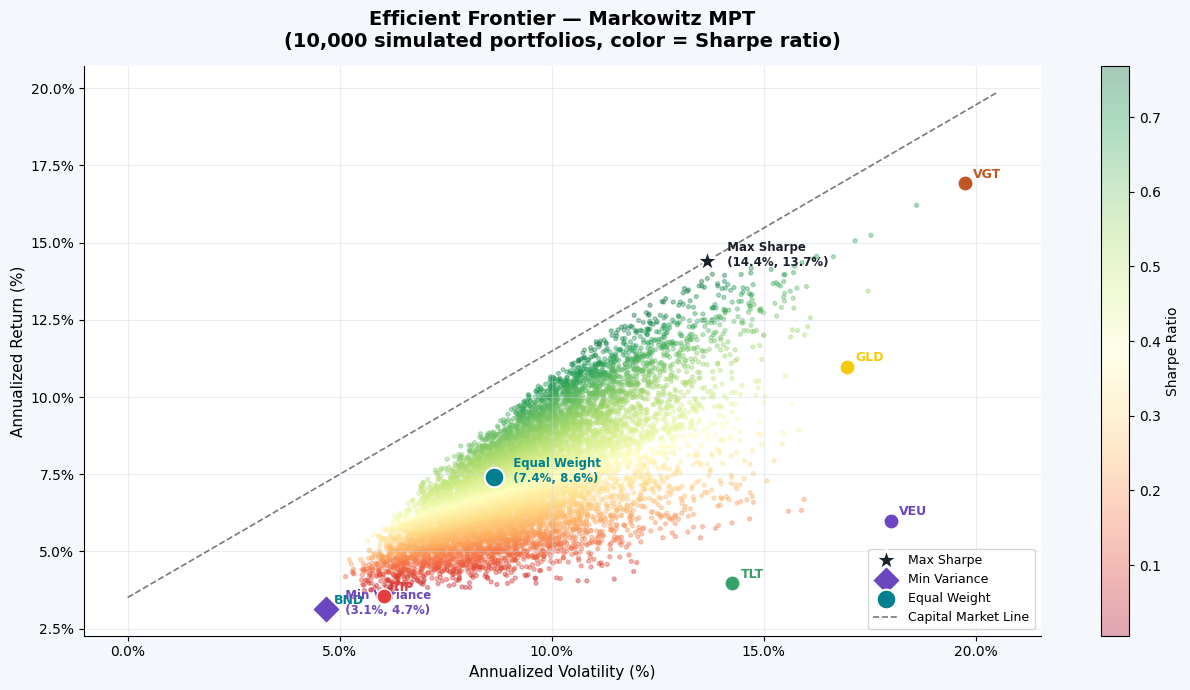

In [12]:
# ── Cell 6: Efficient Frontier Plot ──────────────────────────────────────────
# Combines the Monte Carlo cloud with the three key portfolios.
# Color = Sharpe ratio — shows the Capital Market Line gradient.

fig, ax = plt.subplots(figsize=(13, 7))

# Monte Carlo scatter — colored by Sharpe
sc = ax.scatter(
    sim_df["Vol"], sim_df["Return"],
    c=sim_df["Sharpe"], cmap="RdYlGn",
    alpha=0.35, s=8, zorder=1
)
plt.colorbar(sc, ax=ax, label="Sharpe Ratio")

# Individual assets
for asset, color in zip(ASSETS, PALETTE):
    i   = ASSETS.index(asset)
    av  = vol[i]
    ar  = mu_arr[i] * 100
    ax.scatter(av, ar, s=120, color=color, zorder=5, edgecolors="white", linewidths=1)
    ax.annotate(asset, (av, ar), textcoords="offset points",
                xytext=(6, 4), fontsize=9, color=color, fontweight="bold")

# Key portfolios
key_portfolios = [
    (w_sharpe, "Max Sharpe",   "#1A202C", "*", 280),
    (w_minvar, "Min Variance", "#6B46C1", "D", 220),
    (w_equal,  "Equal Weight", "#028090", "o", 200),
]

for w, label, color, marker, size in key_portfolios:
    wv = w.values
    rv = wv @ mu_arr * 100
    vv = np.sqrt(wv @ cov_arr @ wv) * 100
    ax.scatter(vv, rv, s=size, color=color, marker=marker,
               zorder=6, edgecolors="white", linewidths=1.5, label=label)
    ax.annotate(f"  {label}\n  ({rv:.1f}%, {vv:.1f}%)",
                (vv, rv), textcoords="offset points",
                xytext=(8, -4), fontsize=8.5, color=color, fontweight="bold")

# Capital Market Line
wv  = w_sharpe.values
vv  = np.sqrt(wv @ cov_arr @ wv) * 100
rv  = wv @ mu_arr * 100
cml_x = np.linspace(0, vv * 1.5, 100)
cml_y = RISK_FREE_ANNUAL * 100 + (rv - RISK_FREE_ANNUAL * 100) / vv * cml_x
ax.plot(cml_x, cml_y, color="#1A202C", linewidth=1.2,
        linestyle="--", alpha=0.6, label="Capital Market Line", zorder=3)

ax.set_xlabel("Annualized Volatility (%)", fontsize=11)
ax.set_ylabel("Annualized Return (%)",     fontsize=11)
ax.set_title("Efficient Frontier — Markowitz MPT\n"
             f"({N_SIMULATIONS:,} simulated portfolios, color = Sharpe ratio)",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(fontsize=9, loc="lower right")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 4. Weight Comparison

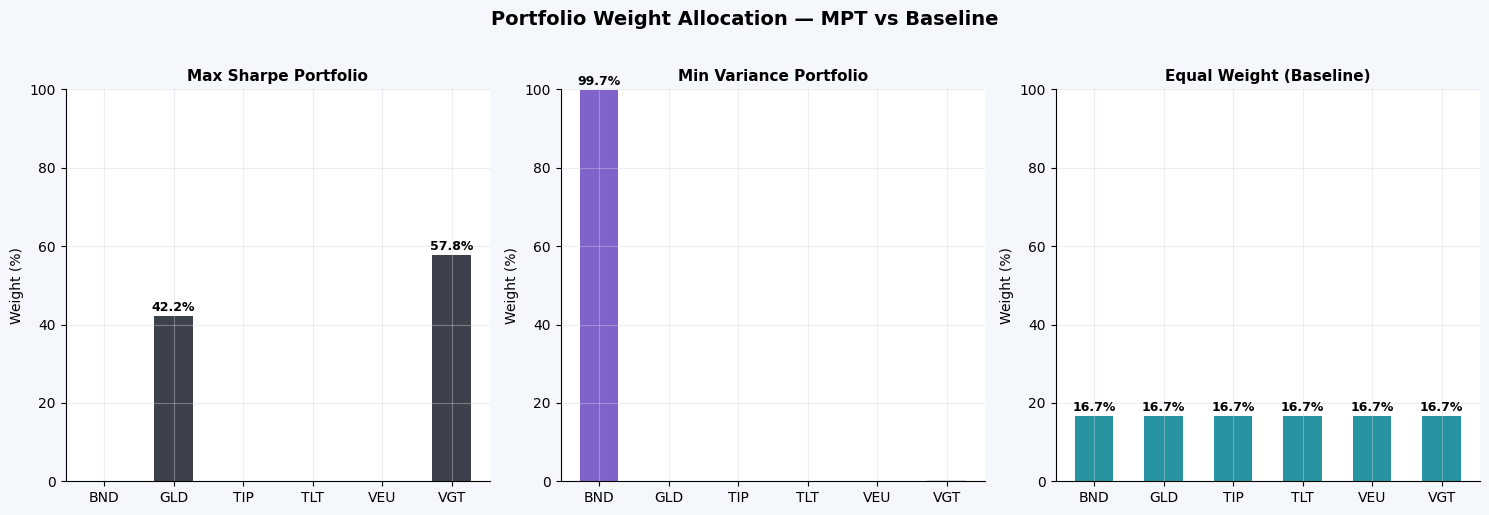

── Weight Allocation (%) ──
     Max Sharpe %  Min Variance %  Equal Weight %
BND          0.00           99.72           16.67
GLD         42.21            0.00           16.67
TIP          0.00            0.00           16.67
TLT          0.00            0.00           16.67
VEU          0.00            0.00           16.67
VGT         57.79            0.28           16.67

── Concentration (Herfindahl Index) — lower = more diversified ──
  Max Sharpe          HHI = 0.5121   (1/N = 0.1667)
  Min Variance        HHI = 0.9945   (1/N = 0.1667)
  Equal Weight        HHI = 0.1667   (1/N = 0.1667)


In [7]:
# ── Cell 7: Weight Comparison ─────────────────────────────────────────────────
# Shows how MPT concentrates weight differently from equal weight.
# MPT is known for corner solutions — it often assigns extreme weights
# to a handful of assets and zeros out the rest.

weight_df = pd.DataFrame({
    "Max Sharpe %"  : w_sharpe * 100,
    "Min Variance %": w_minvar * 100,
    "Equal Weight %": w_equal  * 100,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    ("Max Sharpe %",   "Max Sharpe Portfolio",   "#1A202C"),
    ("Min Variance %", "Min Variance Portfolio",  "#6B46C1"),
    ("Equal Weight %", "Equal Weight (Baseline)", "#028090"),
]

for ax, (col, title, color) in zip(axes, configs):
    vals   = weight_df[col]
    colors = [color if v > 0.5 else "#CBD5E0" for v in vals]
    bars   = ax.bar(ASSETS, vals, color=colors, alpha=0.85, width=0.55)
    for bar, val in zip(bars, vals):
        if val > 0.5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f"{val:.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel("Weight (%)")
    ax.set_ylim(0, 100)
    ax.set_xlabel("")

fig.suptitle("Portfolio Weight Allocation — MPT vs Baseline",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("── Weight Allocation (%) ──")
print(weight_df.round(2).to_string())

# Concentration metric: Herfindahl index (sum of squared weights)
# 1/N = perfectly diversified, 1.0 = fully concentrated
print("\n── Concentration (Herfindahl Index) — lower = more diversified ──")
for col, label in [("Max Sharpe %", "Max Sharpe"),
                   ("Min Variance %", "Min Variance"),
                   ("Equal Weight %", "Equal Weight")]:
    w    = weight_df[col].values / 100
    hhi  = np.sum(w**2)
    print(f"  {label:<18}  HHI = {hhi:.4f}   (1/N = {1/N:.4f})")

## 5. Cumulative Performance

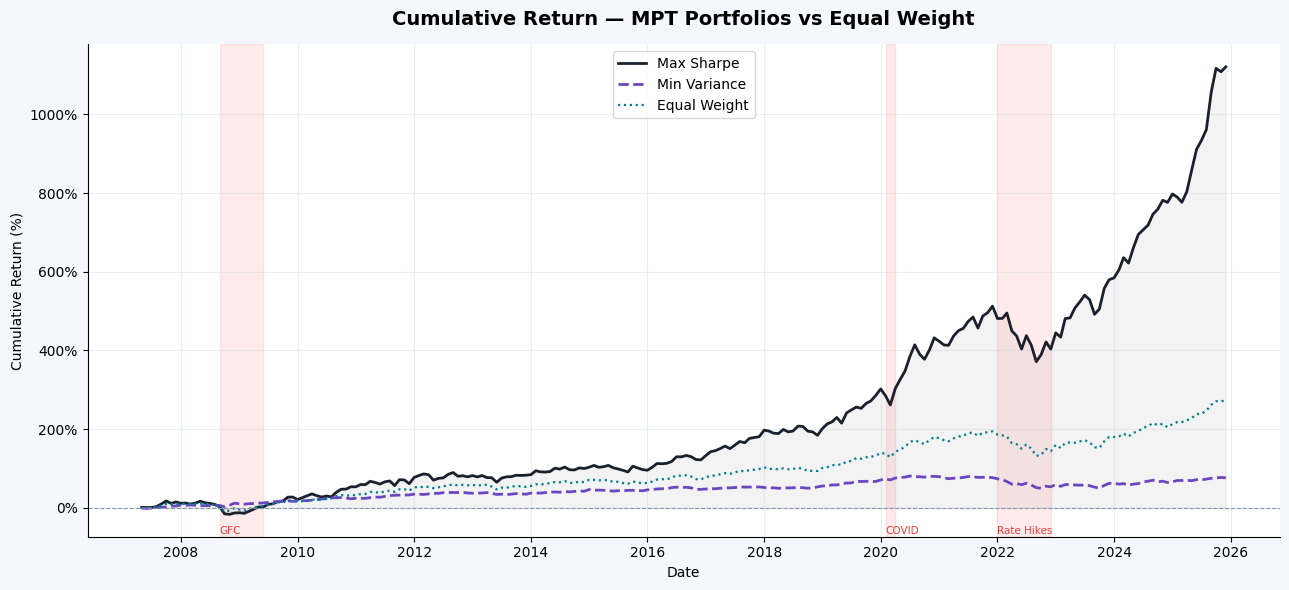

── Final Cumulative Returns ──
  Max Sharpe   : 1120.7%
  Min Variance : 76.3%
  Equal Weight : 271.1%


In [8]:
# ── Cell 8: Cumulative Performance ───────────────────────────────────────────
# Applies static (buy-and-hold) MPT weights to historical returns.
# Important caveat: weights are derived from the FULL sample — this is
# in-sample and will overstate real forward performance (look-ahead bias).
# Rolling rebalancing in Cell 10 addresses this.

sharpe_ret = (rets * w_sharpe).sum(axis=1)
minvar_ret = (rets * w_minvar).sum(axis=1)
equal_ret  = (rets * w_equal ).sum(axis=1)

sharpe_growth = (1 + sharpe_ret).cumprod()
minvar_growth = (1 + minvar_ret).cumprod()
equal_growth  = (1 + equal_ret ).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot((sharpe_growth - 1) * 100, color="#1A202C",  linewidth=2,   label="Max Sharpe")
ax.plot((minvar_growth - 1) * 100, color="#6B46C1",  linewidth=2,   label="Min Variance",  linestyle="--")
ax.plot((equal_growth  - 1) * 100, color="#028090",  linewidth=1.6, label="Equal Weight",  linestyle=":")

ax.fill_between(sharpe_growth.index, (sharpe_growth - 1) * 100, 0,
                alpha=0.05, color="#1A202C")

for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="red", zorder=0)
    ax.text(pd.Timestamp(start), ax.get_ylim()[0] * 0.92, label,
            fontsize=7.5, color="#E53E3E", ha="left")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return — MPT Portfolios vs Equal Weight",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("── Final Cumulative Returns ──")
print(f"  Max Sharpe   : {(sharpe_growth.iloc[-1]-1)*100:.1f}%")
print(f"  Min Variance : {(minvar_growth.iloc[-1]-1)*100:.1f}%")
print(f"  Equal Weight : {(equal_growth.iloc[-1]-1)*100:.1f}%")

## 6. Drawdown Paths

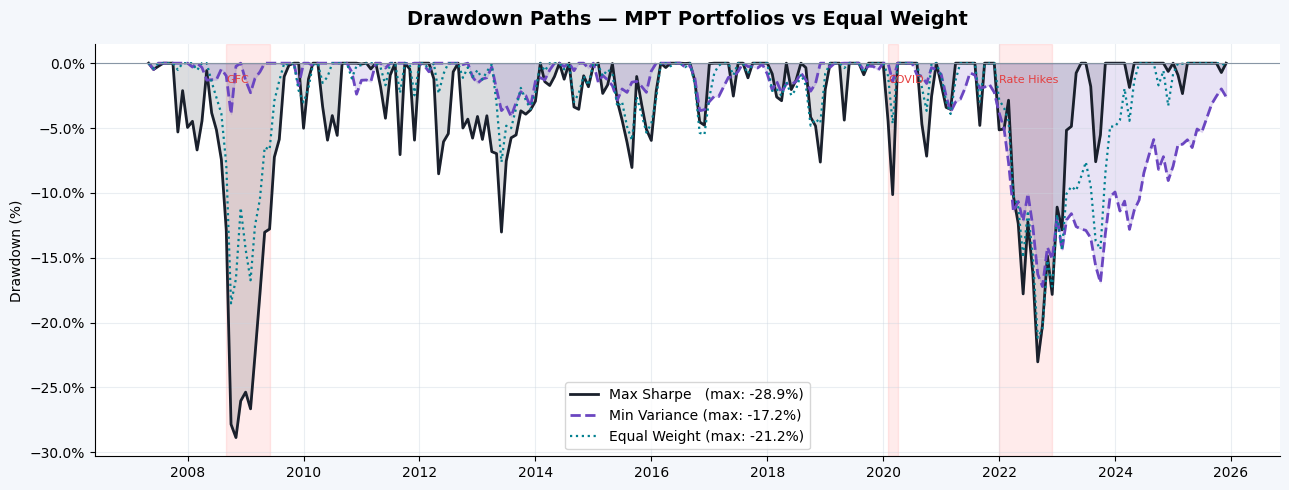

In [9]:
# ── Cell 9: Drawdown Paths ────────────────────────────────────────────────────

def drawdown_series(returns_series):
    cum         = (1 + returns_series).cumprod()
    rolling_max = cum.cummax()
    return (cum - rolling_max) / rolling_max * 100

dd_sharpe = drawdown_series(sharpe_ret)
dd_minvar = drawdown_series(minvar_ret)
dd_equal  = drawdown_series(equal_ret)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(dd_sharpe.index, dd_sharpe, 0, alpha=0.15, color="#1A202C")
ax.fill_between(dd_minvar.index, dd_minvar, 0, alpha=0.15, color="#6B46C1")

ax.plot(dd_sharpe, color="#1A202C", linewidth=2,   label=f"Max Sharpe   (max: {dd_sharpe.min():.1f}%)")
ax.plot(dd_minvar, color="#6B46C1", linewidth=2,   label=f"Min Variance (max: {dd_minvar.min():.1f}%)", linestyle="--")
ax.plot(dd_equal,  color="#028090", linewidth=1.6, label=f"Equal Weight (max: {dd_equal.min():.1f}%)",  linestyle=":")

for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="red", zorder=0)
    ax.text(pd.Timestamp(start), -1.5, label, fontsize=8, color="#E53E3E", ha="left")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — MPT Portfolios vs Equal Weight",
             fontsize=14, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Rolling Rebalancing Simulation

A real robo-advisor does not set weights once and hold forever.
It re-optimizes periodically using a rolling window of historical data.
This cell simulates that process and shows how weights evolve over time.

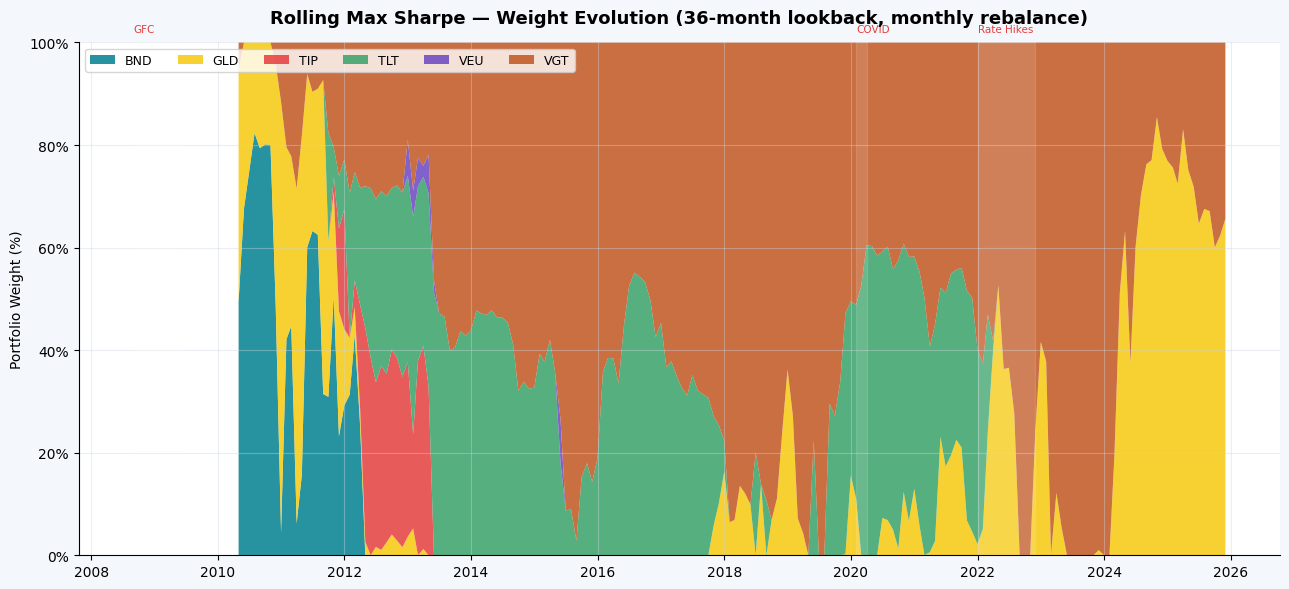

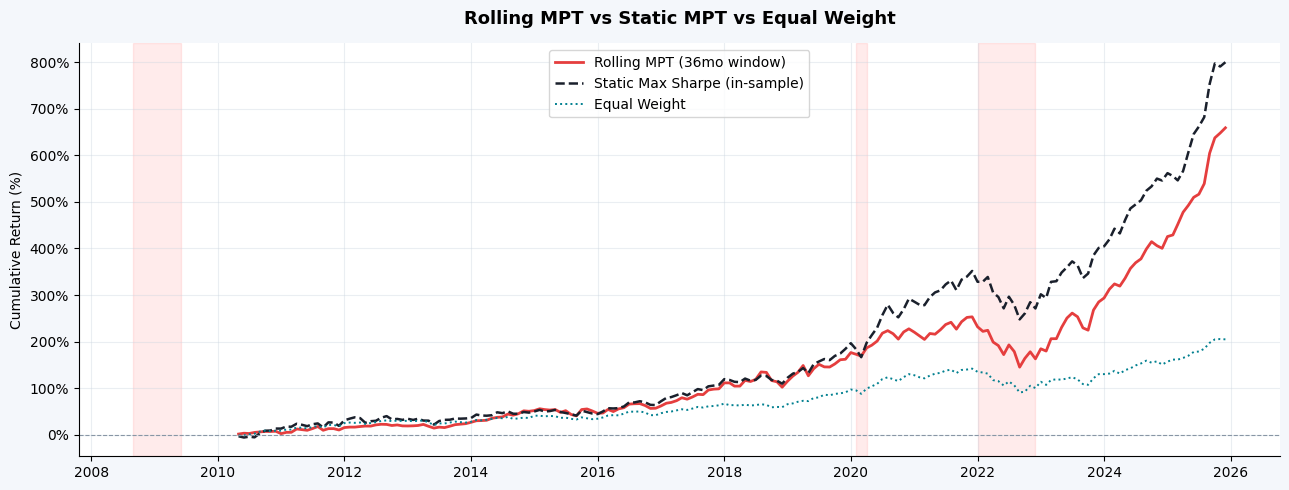

Rolling MPT final return : 659.0%
Static Max Sharpe        : 799.9%
Equal Weight             : 204.8%


In [10]:
# ── Cell 10: Rolling Rebalancing Simulation ───────────────────────────────────
#
# At each rebalance date:
#   1. Use the past LOOKBACK months of returns to estimate mu and cov
#   2. Solve for Max Sharpe weights on that window
#   3. Apply those weights to the next month's return
#
# This eliminates look-ahead bias and reflects a realistic robo-advisor cadence.
#
# LOOKBACK = 36 months (3 years) — standard for robo-advisors
# REBALANCE_FREQ = 1 — monthly rebalancing (most aggressive / most realistic)

LOOKBACK       = 36
REBALANCE_FREQ = 1

rolling_weights = []
rolling_dates   = []
rolling_returns = []

for i in range(LOOKBACK, len(rets)):
    window = rets.iloc[i - LOOKBACK : i]

    mu_w  = window.mean() * 12
    cov_w = window.cov()  * 12

    # Solve Max Sharpe on this window
    def neg_sharpe_w(w, mu=mu_w.values, cov=cov_w.values):
        r = w @ mu
        v = np.sqrt(w @ cov @ w)
        return -(r - RISK_FREE_ANNUAL) / v if v > 0 else 0

    try:
        res = sco.minimize(
            neg_sharpe_w, np.ones(N) / N,
            method="SLSQP",
            bounds=[(0.0, 1.0)] * N,
            constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1},
            options={"ftol": 1e-10, "maxiter": 500}
        )
        w_opt = res.x
    except Exception:
        w_opt = np.ones(N) / N    # fallback to equal weight on failure

    # Apply to next month's actual return
    next_ret = rets.iloc[i]
    port_r   = w_opt @ next_ret.values

    rolling_weights.append(w_opt)
    rolling_dates.append(rets.index[i])
    rolling_returns.append(port_r)

rolling_w_df  = pd.DataFrame(rolling_weights, index=rolling_dates, columns=ASSETS)
rolling_ret_s = pd.Series(rolling_returns,    index=rolling_dates)

# ── Plot 1: Rolling weight evolution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.stackplot(rolling_w_df.index,
             [rolling_w_df[col] * 100 for col in ASSETS],
             labels=ASSETS, colors=PALETTE, alpha=0.85)
for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color="white", zorder=2)
    ax.text(pd.Timestamp(start), 102, label, fontsize=7.5, color="#E53E3E", ha="left")
ax.set_title(f"Rolling Max Sharpe — Weight Evolution ({LOOKBACK}-month lookback, monthly rebalance)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Portfolio Weight (%)")
ax.set_ylim(0, 100)
ax.legend(loc="upper left", fontsize=9, ncol=N)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

# ── Plot 2: Rolling vs static performance ────────────────────────────────────
rolling_growth = (1 + rolling_ret_s).cumprod()
static_growth  = (1 + sharpe_ret.loc[rolling_ret_s.index]).cumprod()
equal_growth_r = (1 + equal_ret.loc[rolling_ret_s.index]).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot((rolling_growth - 1) * 100, color="#E53E3E",  linewidth=2,   label=f"Rolling MPT ({LOOKBACK}mo window)")
ax.plot((static_growth  - 1) * 100, color="#1A202C",  linewidth=1.8, label="Static Max Sharpe (in-sample)", linestyle="--")
ax.plot((equal_growth_r - 1) * 100, color="#028090",  linewidth=1.4, label="Equal Weight", linestyle=":")
ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
for start, end, label in CRISES:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="red", zorder=0)
ax.set_title("Rolling MPT vs Static MPT vs Equal Weight",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Rolling MPT final return : {(rolling_growth.iloc[-1]-1)*100:.1f}%")
print(f"Static Max Sharpe        : {(static_growth.iloc[-1]-1)*100:.1f}%")
print(f"Equal Weight             : {(equal_growth_r.iloc[-1]-1)*100:.1f}%")

## 8. Performance Summary

── Performance Summary ──
                       Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio
Max Sharpe (static)              14.94         13.04         0.881            -23.03         0.649
Min Variance (static)             2.58          4.61        -0.189            -17.22         0.150
Max Sharpe (rolling)             13.84         12.99         0.800            -30.59         0.453
Equal Weight                      7.46          8.09         0.495            -21.17         0.352


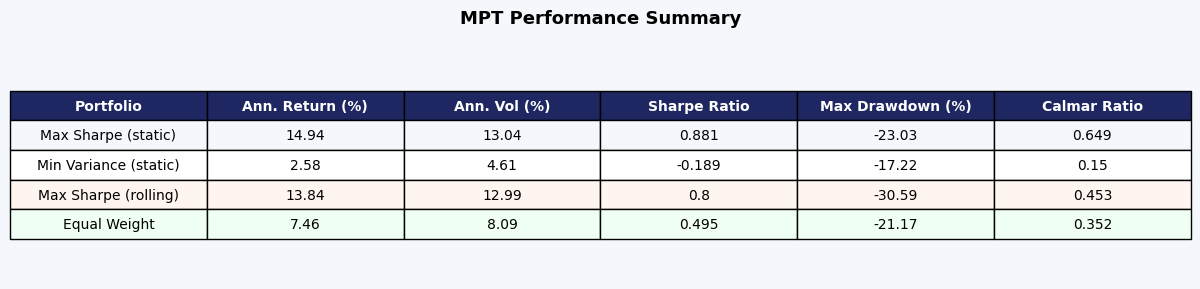

In [11]:
# ── Cell 11: Performance Summary ─────────────────────────────────────────────
# Consistent with risk_parity_erc.ipynb performance_stats() function.
# Sharpe uses monthly Rf correctly: (mean - monthly_Rf) * 12 / (std * sqrt(12))

def performance_stats(returns_series, label):
    """Annualized performance metrics from monthly returns."""
    ann_return = returns_series.mean() * 12 * 100
    ann_vol    = returns_series.std()  * np.sqrt(12) * 100
    sharpe     = (returns_series.mean() - RISK_FREE_MONTHLY) * 12 / \
                 (returns_series.std() * np.sqrt(12))

    cum         = (1 + returns_series).cumprod()
    rolling_max = cum.cummax()
    max_dd      = ((cum - rolling_max) / rolling_max).min() * 100

    # Calmar ratio = annualized return / |max drawdown|
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return pd.Series({
        "Ann. Return (%)"  : round(ann_return, 2),
        "Ann. Vol (%)"     : round(ann_vol,    2),
        "Sharpe Ratio"     : round(sharpe,     3),
        "Max Drawdown (%)" : round(max_dd,     2),
        "Calmar Ratio"     : round(calmar,     3),
    }, name=label)

# Align all series to the rolling window period for fair comparison
idx = rolling_ret_s.index

summary = pd.DataFrame([
    performance_stats(sharpe_ret.loc[idx],   "Max Sharpe (static)"),
    performance_stats(minvar_ret.loc[idx],   "Min Variance (static)"),
    performance_stats(rolling_ret_s,         "Max Sharpe (rolling)"),
    performance_stats(equal_ret.loc[idx],    "Equal Weight"),
])

print("── Performance Summary ──")
print(summary.to_string())

# ── Visual summary table ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")

col_labels = ["Portfolio"] + list(summary.columns)
row_data   = [[idx] + list(summary.loc[idx]) for idx in summary.index]

table = ax.table(
    cellText=row_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#1E2761")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Row shading
row_colors = ["#F4F7FB", "white", "#FFF5F0", "#F0FFF4"]
for i, rc in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(rc)

ax.set_title("MPT Performance Summary", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Summary

**What MPT does well**
- Produces the mathematically optimal risk/return tradeoff given historical inputs
- Max Sharpe portfolio clearly sits on the efficient frontier above all random portfolios
- Min Variance delivers the lowest drawdowns — relevant for capital preservation profiles

**What MPT struggles with (robo-advisor implications)**
- **Concentration risk**: MPT frequently produces corner solutions — 80%+ in one or two assets, zeros elsewhere. This is a known pathology of unconstrained MVO.
- **Input sensitivity**: Small changes in expected returns produce large swings in weights. The rolling simulation exposes this: weights jump significantly month-to-month.
- **Look-ahead bias**: Static weights derived from the full sample overstate real performance. The rolling model is the honest comparison.
- **Estimation error**: Historical mu is a noisy estimate of future returns. The covariance matrix is more stable but still regime-dependent (see 2022).

**In the 5-strategy comparison**
- MPT will likely show the highest in-sample Sharpe but the widest gap between static and rolling performance
- Risk Parity sidesteps the estimation-error problem entirely by ignoring expected returns
- This gap IS the robo-advisor marketing story: complexity vs. actual investor outcomes